In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)_9절~14절</font>

# 9절. 데이터 그룹화 및 집계

In [8]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [9]:
#  그룹화 방법 2) 그룹핑 할 때 index를 컬럼 데이터로 편입(reset_index()가 필요X)
#    df.groupby(by=[그룹핑할열이름], as_index=False)[함수 적용해서 출력할 열들].기초통계함수()
#    [함수 적용해서 출력할 열들] 생략시 모든 열이 적용됨.
iris.groupby('Species')[ ['Sepal.Length','Sepal.Width'] ].sum()

,Sepal.Length,Sepal.Width
Species,,
setosa,250.3,171.4
versicolor,296.8,138.5
virginica,329.4,148.7


In [10]:
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum   # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [11]:
# setosa, virginica의 집계만
iris_grouped_sum.loc[ ['setosa', 'virginica'] ]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [12]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [13]:
iris_grouped_sum.reset_index(inplace=True) # 인덱스를 컬럼으로 편입시킴

In [14]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [15]:
# setosa, virginica의 집계만
iris_grouped_sum[ (iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica') ]
iris_grouped_sum[iris_grouped_sum.Species.isin( ['setosa', 'virginica'] ) ]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [16]:
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [17]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[ ['Sepal.Length','Sepal.Width'] ]
iris.groupby('Species')[ ['Sepal.Length','Sepal.Width'] ].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [18]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 시리즈로 출력(1차원)
iris.groupby('Species')[ ['Sepal.Length'] ].sum() # 결과가 시리즈로 출력(2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [19]:
# 그룹화 방법 1)
# df.groupby(by=[그룹핑할열이름들], as_index=T or F)[함수 적용해서 출력할 열들].함수명()
# 그룹화 방법 2)
# df.pivot_table( index='그룹핑 할 열들',   values='함수 적용해서 출력할 열들',   aggfunc=함수명(기본값:mean) )
g = iris.pivot_table(index='Species') # values= 안쓰면 모든 열 출력 # aggfunc='mean'

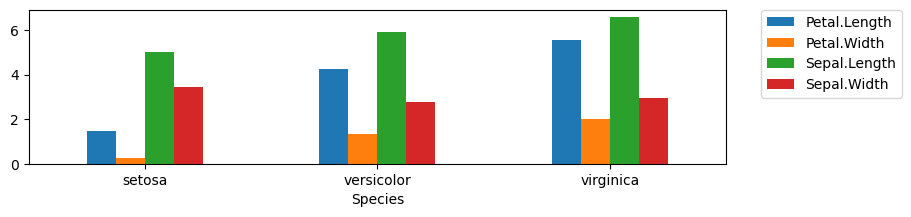

In [20]:
# 범례를 밖으로 : 시각화20page. 판다스60page.
import matplotlib.pyplot as plt
g.plot( kind='bar', figsize=(9,2), rot=0 )
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [21]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')[ ['Sepal.Length'] ].count()
iris['Species'].value_counts() # 정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [22]:
# 임의로 각열마다 결측치를 할당(0번째 열은 결측치1 / 1번째 열은 결측치2 / 2번째 열은 결측치3 / 3번째 열은 결측치 4)
import numpy as np
import random
# random.sample(range(0,150), 3)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan # 1번만 실행

In [23]:
iris.isna().head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [24]:
# 열별 결측치를 제외한 데이터 개수
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,50,48,49,49
versicolor,47,50,50,49
virginica,50,48,50,50


### 다중열로 그룹화

In [25]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [26]:
# iris로 다중열 그룹화를 하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species 3그룹, num 6그룹
iris['num'] = np.array( [[i]*25 for i in range(6)] ).flatten() # 25개씩 6개의 그룹
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [27]:
# 종별, num별 합계
r = iris.groupby( ['Species', 'num'] ).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         83.6          36.5          6.2
           1           119.9         84.4          36.6          5.6
versicolor 2           150.3         69.4         107.8         33.6
           3           146.5         66.3          94.4         32.7
virginica  4           164.4         73.2         141.0         51.1
           5           165.0         75.5         136.6         45.8

In [28]:
r.loc[['setosa','virginica']] # setosa와 virginica의 합계만

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         83.6          36.5          6.2
          1           119.9         84.4          36.6          5.6
virginica 4           164.4         73.2         141.0         51.1
          5           165.0         75.5         136.6         45.8

In [29]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,83.6,36.5,6.2
virginica,5,165.0,75.5,136.6,45.8


In [30]:
# 종별, num별 합계
iris.pivot_table(index=['Species', 'num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.460000     0.248000      5.028000     3.483333
           1        1.464000     0.243478      4.995833     3.376000
versicolor 2        4.312000     1.344000      6.012000     2.776000
           3        4.290909     1.308000      5.860000     2.762500
virginica  4        5.640000     2.044000      6.576000     2.928000
           5        5.464000     1.991304      6.600000     3.020000

In [31]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  49.000000   50.000000  50.000000
             mean    5.012245    5.936000   6.588000
             std     0.353337    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  49.000000   49.000000  50.000000
             mean    3.428571    2.769388   2.974000
             std     0.382971    0.317020   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.700000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
Petal.Length count  50.000000   47.000000  50.000000
             mean    1.462000    4.302128   5.552000
             std     0.173664    0.446479   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.400000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
Petal.Width  count  48.000000   50.000000  48.000000
             mean    0.245833    1.326000   2.018750
             std     0.107106    0.197753   0.277263
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

## 9.2 그룹간 데이터 처리

In [32]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [33]:
iris_grouped = iris.groupby('Species')
iris_grouped

In [34]:
# 종별 상위 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.head(3))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica


In [35]:
# 종별 임의의 표본 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.sample(3).sort_index()) # sort_index() 행 순서로 정렬 # .reset_index(drop=True)

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
4,5.0,3.6,1.4,0.2,setosa
19,5.1,3.8,1.5,0.3,setosa
39,5.1,3.4,1.5,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
72,6.3,2.5,4.9,1.5,versicolor
86,6.7,3.1,4.7,1.5,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
118,7.7,2.6,6.9,2.3,virginica
135,7.7,3.0,6.1,2.3,virginica
139,6.9,3.1,5.4,2.1,virginica


In [36]:
# 종별 0,15,30,45번째 행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.iloc[[0,15,30,45]])

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor
95,5.7,3.0,4.2,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica
145,6.7,3.0,5.2,2.3,virginica


In [37]:
## 9.3 데이터프레임 그룹별 인덱싱

In [38]:
#  종별 0,15,30,45번째 행 출력
#  for speciesname, group in iris_grouped:
#     print(speciesname)
#     display(group.iloc[[0,15,30,45]])
r = iris.groupby('Species').take([0,15,30,40])
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species                                                             
setosa     0             5.1          3.5           1.4          0.2
           15            5.7          4.4           1.5          0.4
           30            4.8          3.1           1.6          0.2
           40            5.0          3.5           1.3          0.3
versicolor 50            7.0          3.2           4.7          1.4
           65            6.7          3.1           4.4          1.4
           80            5.5          2.4           3.8          1.1
           90            5.5          2.6           4.4          1.2
virginica  100           6.3          3.3           6.0          2.5
           115           6.4          3.2           5.3          2.3
           130           7.4          2.8           6.1          1.9
           140           6.7          3.1           5.6          2.4

In [39]:
r.loc['versicolor']

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
50,7.0,3.2,4.7,1.4
65,6.7,3.1,4.4,1.4
80,5.5,2.4,3.8,1.1
90,5.5,2.6,4.4,1.2


# 10절. 데이터 구조 변경
- 와이드포맷 <--> 롱포맷
- 와이드포맷(wide format) : 열 단위 데이터 구조4
    * 특징 - 엑셀에서 자주 보는 형태로 모든 데이터가 한눈에 들어옴.
- 롱 포맷(long format) : 행 단위 데이터 구조
    * 특징 - 깔끔한 데이터로 불리며, 컴퓨터와 분석 라이브러리가 선호하는 형태. 하나의 행에 하나의 측정값만 들어가며, 설명해주는 열(속성 변수)이 따로 존재함.
- 판다스 공식문서에 나오는 melt : https://pandas.pydata.org/docs/user_guide/reshaping.html#melt-and--wide-to-long
- Tidy Data : https://vita.had.co.nz/papers/tidy-data.pdf

In [40]:
from statsmodels.api import datasets
airquality = datasets.get_rdataset('airquality').data # 1973년 뉴욕 공기 질 데이터셋
airquality.sample(5).sort_index()

,Ozone,Solar.R,Wind,Temp,Month,Day
13,14.0,274.0,10.9,68,5,14
33,NaN,242.0,16.1,67,6,3
35,NaN,220.0,8.6,85,6,5
73,27.0,175.0,14.9,81,7,13
113,9.0,36.0,14.3,72,8,22


## 10.1 melt를 이용한 언피벗팅(와이드포맷 → 롱포맷)
- df.melt(id_vars, value_vars, var_name, value_name)
- pd.melt(df, id_vars, value_vars, var_name, value_name)

In [41]:
# pd.melt(airquality, id_vars=['Month','Day'])
airquality_melted = airquality.melt(id_vars=['Month','Day'],
                                                               # value_vars=['Ozone', 'Solar.R','Wind','Temp'] melt될 열이름
                                                                                                    )
airquality_melted.sample(5).sort_index()

,Month,Day,variable,value
60,6,30,Ozone,NaN
277,9,2,Solar.R,197.0
298,9,23,Solar.R,139.0
436,9,8,Wind,10.3
558,8,8,Temp,90.0


In [42]:
airquality_melted = airquality.melt(id_vars=['Month','Day'],
                                                               var_name='변수명',   # melt된 데이터의 열이름 변경
                                                                    value_name='값'   # 데이터가 된 열이름 변경
                                                                                                       )
airquality_melted = airquality_melted.sort_values(by=['Month','Day']).reset_index(drop=True)
airquality_melted

,Month,Day,변수명,값
0,5,1,Ozone,41.0
1,5,1,Solar.R,190.0
2,5,1,Wind,7.4
3,5,1,Temp,67.0
4,5,2,Ozone,36.0
...,...,...,...,...
607,9,29,Temp,76.0
608,9,30,Ozone,20.0
609,9,30,Solar.R,223.0
610,9,30,Wind,11.5


## 10.2 pivot_table을 이용한 피벗팅(롱포맷 → 와이드포맷)
- df.pivot_table(index, columns, values)
- pd.pivot_table(df, index, columns, values)

In [43]:
# pd.pivot_table(airquality_melted, index=['Month','Day'], columns='변수명', values='값')
airquality_melted.pivot_table(index=['Month','Day'], columns='변수명', values="값")

변수명        Ozone  Solar.R  Temp  Wind
Month Day                            
5     1     41.0    190.0  67.0   7.4
      2     36.0    118.0  72.0   8.0
      3     12.0    149.0  74.0  12.6
      4     18.0    313.0  62.0  11.5
      5      NaN      NaN  56.0  14.3
...          ...      ...   ...   ...
9     26    30.0    193.0  70.0   6.9
      27     NaN    145.0  77.0  13.2
      28    14.0    191.0  75.0  14.3
      29    18.0    131.0  76.0   8.0
      30    20.0    223.0  68.0  11.5

[153 rows x 4 columns]

In [44]:
airquality2 = airquality_melted.pivot_table(index=['Month', 'Day'], columns='변수명', values='값')
airquality2.columns.name = None
airquality2 = airquality2.reset_index()
airquality2.sample(5).sort_index()

,Month,Day,Ozone,Solar.R,Temp,Wind
15,5,16,14.0,334.0,64.0,11.5
56,6,26,NaN,127.0,78.0,8.0
91,7,31,59.0,254.0,81.0,9.2
93,8,2,9.0,24.0,81.0,13.8
146,9,24,7.0,49.0,69.0,10.3


# 11절. 데이터프레임에 함수 적용시키기
- apply(func, axis) : 데이터프레임이나 시리즈 모두 적용가능
- map(func) : 각 요소별로 func 적용(1차원 시리즈에서만 가능)
- applymap(func) : 각 요소별로 func 적용(데이터프레임에서만 가능)

## 11.1 apply/map

In [45]:
# ex1) 1차원 시리즈에 apply | map 이용
import pandas as pd
member = pd.read_csv('data/ch11_member.csv', )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      int64 
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: int64(1), object(4)
memory usage: 368.0+ bytes


In [46]:
def get_year(datestr):
    return int(datestr.split('-')[0]) # -를 빼고 0번째 열 출력
get_year = lambda x : int(x.split('-')[1])
get_year("1999-01-01")

1

In [47]:
member['Name'] = member['Name'].str.replace('#', '', regex=False)
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길뜽,24,non@not.com,없는구,2000-01-01


In [48]:
member['년'] = member['Birth'].map(lambda datestr : int(datestr.split('-')[0]))
member['Birth'].apply(lambda x : int(x.split('-')[1]))
member

,Name,Age,Email,Address,Birth,년
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999
5,홍길뜽,24,non@not.com,없는구,2000-01-01,2000


In [49]:
# ex2) 2차원 데이터프레임에서 apply(func, axis)

In [50]:
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                                         encoding='cp949')
df_last.sample(5).sort_index()
# df_last[['월']].sample(5).sort_index()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
1323,강원,전용면적 85제곱미터초과 102제곱미터이하,2017,1,2213
2490,광주,모든면적,2018,3,2930
3192,강원,전용면적 60제곱미터초과 85제곱미터이하,2018,11,2380
4648,충남,전용면적 85제곱미터초과 102제곱미터이하,2020,4,3201
9271,인천,전용면적 60제곱미터이하,2024,11,5738


In [51]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [52]:
def year_month(series):
    return "{}-{:02}".format(series['연도'], series['월'])
year_month(df_last.loc[300])

'2016-01'

In [53]:
df_last['연도월'] = df_last.apply(lambda series : "{}-{:02}".format(series['연도'], series['월']), axis=1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
10875,제주,모든면적,2026,5,4473,2026-05
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,2026-05
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,2026-05
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,2026-05
10879,제주,전용면적 102제곱미터초과,2026,5,4350,2026-05


In [54]:
# ex3) 2차원 데이터프레임에서 apply(func, axis=0)
iris.tail(7)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
143,6.8,3.2,5.9,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [55]:
import numpy as np
X = iris.iloc[:,:-1]
avg = np.mean(iris.iloc[:, :-1], axis=0)
avg = X.mean(axis=0) #  열별 평균
avg

Sepal.Length    5.843333
Sepal.Width     3.057333
Petal.Length    3.758000
Petal.Width     1.199333
dtype: float64

In [56]:
# 각 열별 평균과의 거리를 소수점 2자리까지 출력
X.apply(lambda x: round((x-avg), 2), axis=1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,-0.74,0.44,-2.36,-1.0
1,-0.94,-0.06,-2.36,-1.0
2,-1.14,0.14,-2.46,-1.0
3,-1.24,0.04,-2.26,-1.0
4,-0.84,0.54,-2.36,-1.0
...,...,...,...,...
145,0.86,-0.06,1.44,1.1
146,0.46,-0.56,1.24,0.7
147,0.66,-0.06,1.44,0.8
148,0.36,0.34,1.64,1.1


## 11.2 applymap

In [57]:
X.applymap(lambda x : round(x, 3)) # round : 반올림

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


#### ※ 연습예제 - melt() 및 함수 적용시키기 (분양가격 csv 두파일 통합)
- 와이드포맷 → 롱포맷(melt) : 2013~2015년 데이터
- 평당분양가격/3.3 -> 분양가격(제곱미터당 천원)
- 2013년12월 -> 2013과 12을 나눠 '연도'와 '월' 컬럼(apply, map)
- 연습예제2) new_first
- df_last['규모구분']=='모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
- df_last의 지역명 컬럼명을 지역으로 변경
-    -> new_last
- pd.concat([new_first, new_last])

In [58]:
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
0,서울,모든면적,2015,10,5841,2015-10


In [59]:
df_first = pd.read_csv('c:/ai/downloads/sharedata/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [60]:
# 와이드포맷 -> 롱포맷
df_first.melt().head()

,variable,value
0,지역,서울
1,지역,부산
2,지역,대구
3,지역,인천
4,지역,광주


In [61]:
new_first = df_first.melt(id_vars='지역', var_name='연도월', value_name='평당분양가격') #.sample(7).sort_index()
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.5+ KB


In [62]:
# 평당분양가격/3.3 -> 제곱미터당 분양가격
new_first['분양가격(제곱미터당 천원)'] = new_first['평당분양가격'] / 3.3
new_first.tail()

,지역,연도월,평당분양가격,분양가격(제곱미터당 천원)
352,전북,2015년8월,6580,1993.939394
353,전남,2015년8월,6289,1905.757576
354,경북,2015년8월,7037,2132.424242
355,경남,2015년8월,7665,2322.727273
356,제주,2015년8월,7343,2225.151515


In [63]:
df_last.head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
0,서울,모든면적,2015,10,5841,2015-10


In [64]:
# 2013년12월 -> 2013과 12을 나눠 '연도'와 '월' 컬럼(apply, map)
def parse_year(datestr):
    print(datestr.split('년')[0])
(lambda datestr : int(datestr.split('년')[0]))("2013년12월")
def parse_month(datestr):
    return int(datestr.split('년')[1][:-1])
parse_month("2013년12월")

12

In [65]:
new_first['연도월'].map(lambda datestr : int(datestr.split('년')[0]))
new_first['월'] = new_first['연도월'].apply(lambda datestr : int(datestr.split('년')[1][:-1]))
new_first.drop(['연도월','평당분양가격'], axis=1, inplace=True)
new_first.head(1) # 한번만 실행. 연도월이 이미 삭제되어서 없다고 오류가 생김.

,지역,분양가격(제곱미터당 천원),월
0,서울,5511.818182,12


In [66]:
# df_last['규모구분']=='모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원)컬럼만)
new_last = df_last.loc[df_last['규모구분']=='모든면적', ['지역명','연도','월','분양가격(제곱미터당 천원)'] ]
# new_last.columns = ['지역','연도','월','분양가격(제곱미터당 천원)'] - 컬럼명이 적을때만 사용가능해서 비추
new_last.rename(columns={'지역명' : '지역'}, inplace=True) # 지역명 컬럼명을 지역으로 변경
new_last.head(1) # 한번만 실행. 추가적으로 실행하게된다면 지역명이라는 것은 존재하지않기에 수정이 불가능해서 에러

,지역,연도,월,분양가격(제곱미터당 천원)
0,서울,2015,10,5841


In [67]:
# concat
df = pd.concat([new_first, new_last]).reset_index(drop=True) # 같은 컬럼명 기준으로 행 연결 
df.loc[[0,1,2]]

,지역,분양가격(제곱미터당 천원),월,연도
0,서울,5511.818182,12,NaN
1,부산,2457.878788,12,NaN
2,대구,2448.484848,12,NaN


# 12절. 일괄변경하기(결측치나 특정값)
## 12.1 fillna(결측치를 어떤 값으로 대체)
- 대부분의 결측치는 drop하거나, 평균값대체, 중위수(중앙값, 2사분위수)대체, 최빈값댗체, 이전값, 다음값, 그룹별평균값으로 대체

In [68]:
df = pd.DataFrame([[np.nan, 2, np.nan, 0], [3,4,np.nan,1], [np.nan,3,np.nan,5], [np.nan,3,np.nan,4]], columns=list('ABCD'))
df

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [69]:
# 모든 결측치를 무조건 0으로 대체
df.fillna(0)

,A,B,C,D
0,0.0,2,0.0,0
1,3.0,4,0.0,1
2,0.0,3,0.0,5
3,0.0,3,0.0,4


In [70]:
# 결측치를 이전행의 값으로 대체
df.fillna(method='ffill')

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [71]:
# 결측치를 다음행의 값으로 대체
df.fillna(method='bfill')

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [72]:
# 결측치를 열마다 특정값으로 대체
values = {'A':99, 'B':98, 'C':97, 'D':96}
df.fillna(value=values)

,A,B,C,D
0,99.0,2,97.0,0
1,3.0,4,97.0,1
2,99.0,3,97.0,5
3,99.0,3,97.0,4


In [73]:
# 결측치를 각 열의 평균값으로 대체
df.mean(axis=0)
df.fillna(value=df.mean(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [74]:
# 결측치를 각 열의 평균값으로 대체(결측치 대체는 2번째까지만)
df.fillna(value=df.mean(axis=0), limit=2)

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,NaN,3,NaN,4


In [75]:
# 결측치를 각 열의 중위수(중앙값)으로 대체
df.fillna(value=df.median(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [76]:
# 결측치를 각 열의 최빈값으로 대체
df.fillna(df.mode().loc[0])

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


## 12.2 replace(to_value, new_value, inplace=T/F
- to_value를 new_value로 변경
- to_value에는 정규표현식 이용 가능

In [77]:
s = pd.Series([0,1,2,3,None], index=['A','B','C','D','F'])
s.replace(np.nan, 0, inplace=True)
s.replace([0,1], 99) # 0이나 1을 99로 변경

A    99.0
B    99.0
C     2.0
D     3.0
F    99.0
dtype: float64

In [78]:
s = pd.Series([0,1,2,3,None])
s.replace([0,1,2],[100,101,102])

0    100.0
1    101.0
2    102.0
3      3.0
4      NaN
dtype: float64

In [79]:
df = pd.DataFrame({'A' : ['bat', 'foo', 'bait'], 'B' :['abc','bac','xyz']})
df

,A,B
0,bat,abc
1,foo,bac
2,bait,xyz


In [80]:
# 전부 다 같은 출력이 나옴. 1번과 2번을 주로 사용
df.replace('ba.+','XX', regex=True)
df.replace('^ba.+$','XX', regex=True)
df.replace(regex='ba.+', value='XX')
df.replace(regex=['ba.+', ], value='XX')

,A,B
0,XX,abc
1,foo,XX
2,XX,xyz


In [81]:
df.replace({'A':'Bat', 'B':'abc'}, 'XX')

,A,B
0,bat,XX
1,foo,bac
2,bait,xyz


## 12.3 where(조건),mask(조건)

In [82]:
# 넘파이 where
a = np.array([1,2,3,4,5,6])
np.where(a>3)

(array([3, 4, 5], dtype=int64),)

In [83]:
s = pd.Series(range(10,20))
s

0    10
1    11
2    12
3    13
4    14
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [84]:
# 15이상
s[s>=15]

5    15
6    16
7    17
8    18
9    19
dtype: int64

In [85]:
s.where(s>=15, other=-1) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않는 데이터는 결측치

0    -1
1    -1
2    -1
3    -1
4    -1
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [86]:
s.mask(s>=15) # 조건이 만족되는 데이터만 결측치

0    10.0
1    11.0
2    12.0
3    13.0
4    14.0
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
dtype: float64

## 12.4 dropna
- 결측치가 있는 데이터 누락(행기준, 열기준)

In [87]:
df = pd.DataFrame({'name' : ['홍','김', np.nan, np.nan], 'age' : [np.nan,20,30,np.nan], 'born' : ['서울','부산',np.nan,'']})
df

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,


In [88]:
df.dropna(# axis=0 결측치가 하나라도 있는 행을 drop
                 # inpalce=True가 아니면 return 
                                                                                    )

,name,age,born
1,김,20.0,부산


In [89]:
df.dropna(thresh=2) # 결측치가 아닌값이 2개 이상이면 drop안함

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산


In [90]:
df.dropna(subset=['name','age']) # name열과 born열에 결측치가 하나라도 있는 행 drop

,name,age,born
1,김,20.0,부산


In [91]:
df.dropna(how='all') # 모두 결측치인 행 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,


In [92]:
df.dropna(axis=1, how='all') # 모두 결측치인 열은 drop

,name,age,born
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,


### ※ iris 결측치를 열별 평균으로 대체(교안 80p : fillna)

In [93]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [94]:
iris.isna().sum() # 열마다 결측치 개수
iris.isnull().sum()

Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

In [95]:
iris.notna().sum() # 열마다 결측치를 제외한 데이터 개수
iris.notnull().sum()

Sepal.Length    150
Sepal.Width     150
Petal.Length    150
Petal.Width     150
Species         150
dtype: int64

In [96]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [97]:
iris.isna().sum() # 열마다 결측치 갯수
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [98]:
iris.notna().sum() # 열마다 결측치를 제외한 데이터 갯수
iris.notnull().sum()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [99]:
# 1단계 : iris 데이터에서 결측치를 인위적으로 random하게 열 마다 20씩 결측치를 할당한다
import random
print(random.sample(range(iris.shape[0]),20))

[149, 65, 8, 124, 39, 130, 87, 1, 37, 91, 102, 108, 61, 127, 93, 11, 77, 90, 49, 34]


In [100]:
for col in range(iris.shape[1]-1):
    randomidx = random.sample(range(iris.shape[0]), 20)
    # print(randomidx, col)
    iris.iloc[randomidx,col]=np.nan
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [101]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,NaN,1.4,0.2,setosa
2,4.7,3.2,NaN,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,NaN,setosa


In [102]:
# 2단계 : 결측치가 있는 iris데이터를 출력한다
iris[iris['sepal_length'].isna() | iris['sepal_width'].isna() | 
     iris['petal_length'].isnull() | iris['petal_width'].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,NaN,1.4,0.2,setosa
2,4.7,3.2,NaN,0.2,setosa
4,5.0,3.6,1.4,NaN,setosa
5,5.4,NaN,1.7,0.4,setosa
9,4.9,NaN,1.5,0.1,setosa
...,...,...,...,...,...
144,NaN,3.3,5.7,2.5,virginica
146,6.3,2.5,NaN,1.9,virginica
147,6.5,3.0,NaN,NaN,virginica
148,6.2,3.4,NaN,NaN,virginica


In [105]:
# 3단계 : 결측치를 열평균으로 대체된 iris데이터를 출력
iris.iloc[:, :-1].mean(axis=0) # 열평균
iris.mean(axis=0, numeric_only=True) # 열평균
iris_fillna = iris.fillna(value=iris.iloc[:, :-1].mean(axis=0))
iris_fillna.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [ ]:
# 소수점 3자리에서 반올림
iris_fillna.iloc[:, :-1] = iris_fillna.iloc[:, :-1].applymap(lambda x : np.round(x, 3))
iris_fillna

### ※ iris 결측치를 종별, 열별 평균으로 대체(apply적용)

In [119]:
# 결측치를 종별, 열평균으로 대체된 iris데이터를 출력
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [104]:
iris_mean = iris.groupby(by=['species']).mean()
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.992857,3.414286,1.483333,0.251163
versicolor,5.997727,2.775556,4.252174,1.338636
virginica,6.618182,2.965116,5.604762,2.032558


In [109]:
iris.fillna(value=iris_mean).head(3) # 결측치 대체값이 iris_mean이면 대체가 안됨

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,NaN,1.4,0.2,setosa
2,4.7,3.2,NaN,0.2,setosa


In [110]:
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.992857,3.414286,1.483333,0.251163
versicolor,5.997727,2.775556,4.252174,1.338636
virginica,6.618182,2.965116,5.604762,2.032558


In [116]:
iris_mean.loc['setosa','sepal_length']

4.992857142857143

In [138]:
# 0720 오늘 해당 부분 복습 강조
# np.isnan(스칼라값) : nan만 결측치로 인식하고 결측치인지 여부(값이 숫자형이어야 함)
# pd.isna(스칼라값), pd.isnull(스칼라값) : nan과 None을 모두 결측치로 인식, 결측치인지 여부(값이 숫자형이 아니어도)
def fillna_grouped_mean(row):
    row = row.copy()
    for col, item in row.items():
        # print(col,item, row[col])
        # item이 결측치이면 해당 species가져와서 대체할 결측치를 iris_mean.loc[종이름, col]로 대체
        # if col!='species' and np.isnan(item): # 결측치인지 여부
        if pd.isna(item): # 결측치인지 여부
            species = row['species']
            row[col] = iris_mean.loc[species, col] # 종별 열별 평균값으로 대체
    return row
fillna_grouped_mean(iris.iloc[2])

sepal_length       4.7
sepal_width        3.2
petal_length       1.3
petal_width        0.2
species         setosa
Name: 2, dtype: object

In [141]:
iris.apply(fillna_grouped_mean, axis=1).head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 13절. 시리즈
- 1차원 데이터

In [150]:
s = pd.Series([1000,7000,5000], index=['banana', 'mango', 'apple'])
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [151]:
s['banana'], s.banana

(1000, 1000)

In [152]:
s['banana' : 'apple']

banana    1000
mango     7000
apple     5000
dtype: int64

In [153]:
s['watermelon'] = 20000 # 데이터 추가
s

banana         1000
mango          7000
apple          5000
watermelon    20000
dtype: int64

In [154]:
s.drop('watermelon', inplace=True) # 데이터 drop
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [160]:
s = s.sort_index()
s

apple     5000
banana    1000
mango     7000
dtype: int64

In [156]:
s.sort_values() # 값에 의한 정렬(기본은 ascending=Ture 오름차순)

banana    1000
apple     5000
mango     7000
dtype: int64

In [157]:
s.sort_values(ascending=False) # 내림차순

mango     7000
apple     5000
banana    1000
dtype: int64

In [158]:
s.to_frame()

,0
banana,1000
mango,7000
apple,5000


# 연습문제

In [192]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

pandas.core.frame.DataFrame

In [193]:
# 1) iris 데이터에서 처음 다섯개 행만 출력하세요
iris.loc[:4]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [218]:
# 2) iris 데이터를 데이터프레임 변수인 독립변수 X와 종속변수 y로 나누세요. 종속변수는 species 열입니다.
#print(iris.feature_names)
#print(iris['target_names'])
X = iris.iloc[:, :-1].sample(5).sort_index()
print(X, '\n')
y = iris.species.tail(5)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
11            4.8          3.4           1.6          0.2
27            5.2          3.5           1.5          0.2
62            6.0          2.2           4.0          1.0
105           7.6          3.0           6.6          2.1
141           6.9          3.1           5.1          2.3 

145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, dtype: object


In [243]:
# 3) iris 데이터에서 처음 50개행을 빼내서 temp 변수에 저장하세요
temp = iris.iloc[:50,].copy()
temp # 정답
temp.head(1) # 출력 생략

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [244]:
# 4) 3번에서 선택한 데이터프레임의 요약정보를 출력하세요. 모든 열에 대해 요약정보가 출력되어야 합니다.
temp.describe(include='all')

,sepal_length,sepal_width,petal_length,petal_width,species
count,50.00000,50.000000,50.000000,50.000000,50
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.00600,3.428000,1.462000,0.246000,NaN
std,0.35249,0.379064,0.173664,0.105386,NaN
min,4.30000,2.300000,1.000000,0.100000,NaN
25%,4.80000,3.200000,1.400000,0.200000,NaN
50%,5.00000,3.400000,1.500000,0.200000,NaN
75%,5.20000,3.675000,1.575000,0.300000,NaN


In [245]:
# 5) versicolor종의 데이터만 iris_versicolor 변수에 저장하세요
iris_versicolor = iris[iris['species'].str.contains('versicolor')]
iris_versicolor # 정답
iris_versicolor.head(1) # 출력 생략

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor


In [260]:
# 6) 2번의 X와 y변수를 합해서 iris_df 데이터 프레임으로 만드세요
X = iris.iloc[:, :-1].sample(5).sort_index()
y = iris.species.tail(5)
iris_df = pd.concat([X, y]).reset_index(drop=True)
iris_df.sample(10).sort_index()

,sepal_length,sepal_width,petal_length,petal_width,0
0,5.0,3.4,1.6,0.4,NaN
1,5.5,2.3,4.0,1.3,NaN
2,6.6,2.9,4.6,1.3,NaN
3,6.2,2.9,4.3,1.3,NaN
4,5.8,2.7,5.1,1.9,NaN
5,NaN,NaN,NaN,NaN,virginica
6,NaN,NaN,NaN,NaN,virginica
7,NaN,NaN,NaN,NaN,virginica
8,NaN,NaN,NaN,NaN,virginica
9,NaN,NaN,NaN,NaN,virginica


In [267]:
# 7) iris 데이터의 각 열 평균값을 출력하세요
# iris.mean(axis=0) -> species는 평균을 낼 수 없는 문자열이라서 제외하고 출력해야함.
iris.iloc[:,:-1].mean(axis=0)

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [274]:
# 8) iris 데이터의 각 열들 사이의 상관계수를 출력하세요
iris.iloc[:,:-1].corr() # 7번과 유사함

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [285]:
# 9) iris 데이터에서 각 요소들과 변수별 평균과의 차이를 출력하세요. 다음 그림은 처음 다섯 개 행의 출력 결과입니다.
ex9 = iris.iloc[:, :-1] - iris_mean
ex9

,sepal_length,sepal_width,petal_length,petal_width
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
148,NaN,NaN,NaN,NaN
149,NaN,NaN,NaN,NaN
setosa,NaN,NaN,NaN,NaN
versicolor,NaN,NaN,NaN,NaN


In [293]:
# 10) iris 데이터의 종별 평균을 출력하세요
iris.pivot_table(index='species', )
gb = iris.groupby('species').mean()
gb

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [288]:
# 11) iris 데이터에서 각 요소들과 종별 변수의 평균과의 차이를 출력하세요. 각 종별로 3개씩 출력하세요.
# 참고용
# s1 = pd.Series([10,20,30,40])
# s2 = pd.Series([5,10,15])
# s1-s2
mean_by_species = iris.groupby('species').mean()
mean_by_species.loc['setosa']

sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
Name: setosa, dtype: float64

In [292]:
result = iris.apply(lambda row : row - mean_by_species.loc[row.species], axis=1)
result.groupby(iris.species).head(3)

,petal_length,petal_width,sepal_length,sepal_width,species
0,-0.062,-0.046,0.094,0.072,NaN
1,-0.062,-0.046,-0.106,-0.428,NaN
2,-0.162,-0.046,-0.306,-0.228,NaN
50,0.440,0.074,1.064,0.430,NaN
51,0.240,0.174,0.464,0.430,NaN
52,0.640,0.174,0.964,0.330,NaN
100,0.448,0.474,-0.288,0.326,NaN
101,-0.452,-0.126,-0.788,-0.274,NaN
102,0.348,0.074,0.512,0.026,NaN
